# Industrial Surface Defect Classification using Transfer Learning

## Objective

The aim of this project is to automatically classify surface defects in steel materials using real-world industrial image data and a transfer learning approach.

Surface defects such as cracks, scratches, inclusions, and pits commonly occur during manufacturing processes and can significantly affect product quality. Manual inspection of these defects is time-consuming, inconsistent, and difficult to scale.

In this project, we use a dataset containing steel surface images belonging to six different defect categories:
- Crazing  
- Inclusion  
- Patches  
- Pitted Surface  
- Rolled-in Scale  
- Scratches  

All defect types originate from the same manufacturing domain, and learning from all categories together allows the model to capture shared texture and structural patterns present across industrial surfaces.

The problem statement for this project is:

> **Given a steel surface image, predict the type of surface defect present in the image using a pretrained convolutional neural network.**

To solve this problem efficiently, we apply **transfer learning** by reusing a pretrained `MobileNetV2` model as a feature extractor and training only a lightweight classification head. This demonstrates how deep learning models can be adapted to real industrial use cases using limited data and computational resources.

## Business Value

In manufacturing industries such as steel, automotive, and heavy engineering, surface defects can directly impact product quality, safety, customer satisfaction, production cost, and rework rates.

Traditional inspection methods rely heavily on human inspectors, which introduces inconsistency in defect detection. Manual inspection also comes with high operational costs and scalability limitations.

By applying transfer learning, organisations can:
- Reuse pretrained visual intelligence instead of training models from scratch  
- Reduce development and training time  
- Achieve reliable defect detection even with smaller datasets  
- Deploy lightweight models suitable for real-time or edge-based inspection systems

## Dataset Description

This project uses the **NEU Surface Defect Dataset**, a real-world industrial dataset commonly used in manufacturing research and automated inspection systems.

### Dataset Characteristics:
- Images represent steel surface textures captured under industrial conditions  
- Each image belongs to one of six defect categories:
  - Crazing  
  - Inclusion  
  - Patches  
  - Pitted Surface  
  - Rolled-in Scale  
  - Scratches  
- Images are originally grayscale
- The dataset is reasonably balanced across classes  


#### Why this dataset?

- It represents a real industrial computer vision problem
- Defect patterns are texture-based, making it ideal for demonstrating transfer learning  
- The dataset size is moderate, encouraging the use of **partial transfer learning** rather than full model retraining  

## Flow Diagram

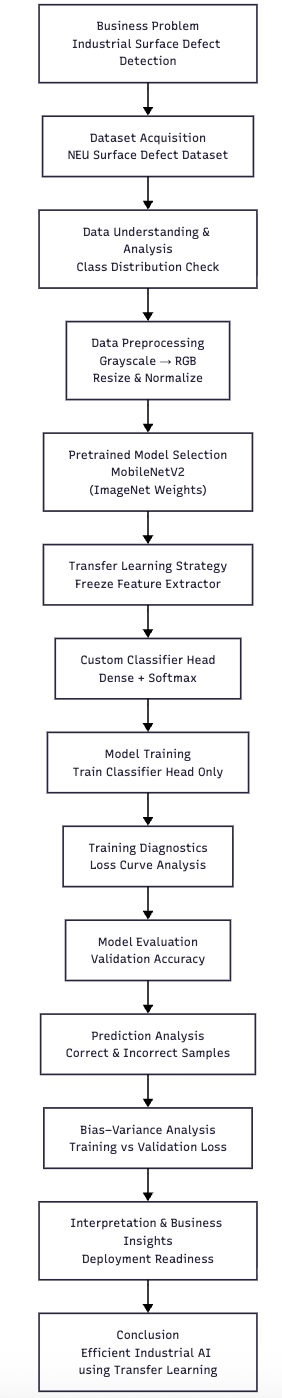

In [ ]:
import sys
print(sys.version)

3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]


### Import Necessary libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets, models

import numpy as np
import matplotlib.pyplot as plt
import os

## 1. Data Loading and PreparationIn any machine learning workflow, understanding and preparing the data correctly is a critical first step. Before building a deep learning model, it is important
to examine how the dataset is structured, how labels are assigned, and how images are preprocessed for training.

This section includes the following steps:
- Understanding the dataset organisation
- Verifying class labels and distributions
- Applying appropriate image transformations for transfer learning
- Development of train loader and validation loader

### 1.1 Dataset Understanding and StructureThe NEU Surface Defect Dataset consists of real-world grayscale images collected from steel manufacturing processes. Each image belongs to one of six surface defect categories.

The dataset is already split into **training** and **validation** sets, and images are organised into class-specific folders. This structure allows us to use PyTorch’s `ImageFolder` utility, which automatically assigns labels based on directory names.

The same directory-based structure is also compatible with TensorFlow, allowing the dataset to be loaded directly using `tf.keras.utils.image_dataset_from_directory`, which infers class labels from folder names in a similar manner.



Before proceeding, we load the dataset and verify:
- Number of images in training and validation sets
- Mapping between class names and numeric labels

#### **1.1.1** Load Images and LabelsLoad the training and validation datasets and check the number of images and the number of categories present

In [ ]:
# Install unzip if not already available
!apt-get install -y unzip

# Unzip the dataset into the data/ directory
!unzip -q data/NEU-DET.zip -d data/

print("Dataset unzipped to data/")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unzip is already the newest version (6.0-26ubuntu3.2).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
Dataset unzipped to data/


In [ ]:
data_dir = 'data/NEU-DET' # Set the root directory for the unzipped dataset
train_dir = os.path.join(data_dir, 'train', 'images')
val_dir = os.path.join(data_dir, 'validation', 'images')

In [ ]:
# Define transformations (empty for now, will be updated later)
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load training and validation images + labels
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)

# Dataset statistics
print(f"Number of training images: {len(train_dataset)}")
print(f"Number of validation images: {len(val_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Class names: {train_dataset.classes}")

# Store class_to_idx for later use
class_to_idx = train_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

Number of training images: 1440
Number of validation images: 360
Number of classes: 6
Class names: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


Here, the image loader automatically assigns numeric labels based on folder names. For example, all images inside the "crazing" folder receive the same label.

This approach reduces manual labeling effort and ensures consistency between directory structure and class definitions.

#### **1.1.2** Check and Visualise Class Distribution

In [ ]:
# Dataset Class Distribution

# Get class counts for training and validation datasets
train_labels = [label for _, label in train_dataset]
train_class_counts = torch.tensor(train_labels).bincount()

val_labels = [label for _, label in val_dataset]
val_class_counts = torch.tensor(val_labels).bincount()

# Print class distribution
print("Training Class Distribution:")
for i, count in enumerate(train_class_counts):
    print(f"  {idx_to_class[i]}: {count.item()} images")

print("\nValidation Class Distribution:")
for i, count in enumerate(val_class_counts):
    print(f"  {idx_to_class[i]}: {count.item()} images")

Training Class Distribution:
  crazing: 240 images
  inclusion: 240 images
  patches: 240 images
  pitted_surface: 240 images
  rolled-in_scale: 240 images
  scratches: 240 images

Validation Class Distribution:
  crazing: 60 images
  inclusion: 60 images
  patches: 60 images
  pitted_surface: 60 images
  rolled-in_scale: 60 images
  scratches: 60 images


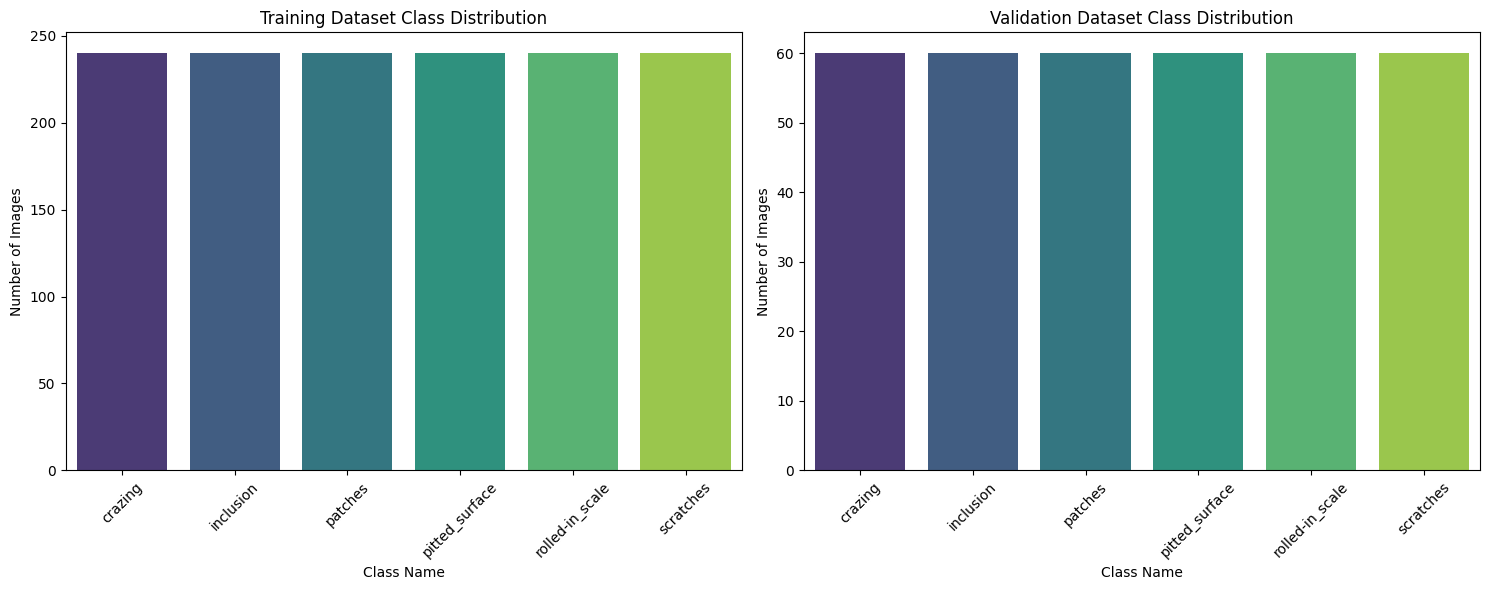

In [ ]:
import seaborn as sns
import pandas as pd

# Visualise class distribution

# Prepare data for plotting
train_df = pd.DataFrame({'class_id': train_labels})
train_df['class_name'] = train_df['class_id'].map(idx_to_class)

val_df = pd.DataFrame({'class_id': val_labels})
val_df['class_name'] = val_df['class_id'].map(idx_to_class)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot training class distribution
sns.countplot(x='class_name', data=train_df, ax=axes[0], palette='viridis')
axes[0].set_title('Training Dataset Class Distribution')
axes[0].set_xlabel('Class Name')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=45)

# Plot validation class distribution
sns.countplot(x='class_name', data=val_df, ax=axes[1], palette='viridis')
axes[1].set_title('Validation Dataset Class Distribution')
axes[1].set_xlabel('Class Name')
axes[1].set_ylabel('Number of Images')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 1.2 Data Preprocessing and TransformationsDeep learning models pretrained on ImageNet expect images to be in a specific format. Although the NEU dataset images are grayscale, ImageNet-pretrained models require 3-channel RGB images with standardised dimensions and normalisation.

#### **1.2.1** Apply Image TransformationsTo ensure compatibility, we apply the following transformations:
- Convert grayscale images to RGB
- Resize images to a fixed resolution
- Normalize using ImageNet mean and standard deviation

These transformations are provided in [`transforms`](https://docs.pytorch.org/vision/0.24/transforms.html) from `torchvision`, while in TensorFlow the same preprocessing steps are applied using [`tf.image`](https://www.tensorflow.org/api_docs/python/tf/image) operations and `tf.keras.layers` within the input pipeline.

In PyTorch, normalization can be performed using `Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)`.

In TensorFlow, the same effect is achieved by explicitly standardising the images with the ImageNet statistics, i.e. subtracting `IMAGENET_MEAN` and dividing by `IMAGENET_STD` using `tf.image` operations or a custom `tf.keras.layers.Layer` within the preprocessing pipeline.

In [ ]:
# Image Transformations

import torchvision.transforms as T

# ImageNet statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Define the transformations
# Added explicit RGB conversion to handle grayscale inputs
data_transforms = {
    'train': T.Compose([
        T.Lambda(lambda x: x.convert('RGB')),
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ]),
    'val': T.Compose([
        T.Lambda(lambda x: x.convert('RGB')),
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ]),
}

# Re-load datasets with transformations applied
train_dataset.transform = data_transforms['train']
val_dataset.transform = data_transforms['val']

print("Transformations applied.")

Transformations applied.


##### Note on ImageNet Statistics

The `IMAGENET_MEAN` and `IMAGENET_STD` values used below are not arbitrary. They represent the global average color and variance across the **ImageNet** dataset (which contains over 14 million images).

*   **Mean:** `[0.485, 0.456, 0.406]`
*   **Std Dev:** `[0.229, 0.224, 0.225]`

**Why do we use them?**  
Since we are using a **pretrained model** (MobileNetV2), the model has already learned to extract features based on these specific input distributions. Normalizing our industrial dataset with these same values ensures that the input 'looks' statistically similar to what the model was originally trained on, leading to better feature extraction and faster convergence.

At this stage, the dataset is fully prepared for training a transfer learning model. Images are correctly formatted, normalized, and labeled, ensuring a smooth transition into model design and training.

#### **1.2.2** Create DataLoaders for both the training and validation datasetsDeep learning models are trained on data in **batches** rather than loading the entire dataset into memory at once.

PyTorch provides the [`DataLoader`](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) utility to batch the data, shuffle training samples and load data efficiently during training. For Tensorflow, you can use similar functionality provided by [`tf.data.Dataset` API](https://www.tensorflow.org/api_docs/python/tf/data/Dataset), which supports efficient batching, shuffling, prefetching, and parallel data loading within the input pipeline.

In [ ]:
# DataLoader Creation

batch_size = 32

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"DataLoaders created with batch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

DataLoaders created with batch size: 32
Number of training batches: 45
Number of validation batches: 12


##### Note on the Purpose of DataLoaders

Creating **DataLoaders** is a standard practice in deep learning for several key reasons:

1.  **Efficiency (Batching)**: It handles 'batching' so the model processes small groups of images (e.g., 32) at once. This strikes a balance between processing speed and hardware memory limits.
2.  **Memory Management**: It loads images from the disk into RAM only when they are needed for the current training step, preventing the system from running out of memory.
3.  **Speed (Parallelism)**: By using `num_workers`, the DataLoader can fetch and preprocess the next batch of images in the background while the GPU/CPU is busy training on the current batch, significantly reducing idle time.

##### Why Batch Size 32?

A batch size of **32** is a standard deep learning heuristic that balances several factors:

*   **Efficiency**: It aligns with power-of-two memory architectures for optimal hardware utilization.
*   **Generalization**: Smaller batches introduce enough gradient noise to help the optimizer escape sharp local minima and generalize better to new data.
*   **Convergence**: It provides a stable gradient estimate that is more computationally efficient than very large or very small batches.

##### Note on Shuffling Strategy

*   **Training Loader (`shuffle=True`)**: Shuffling is enabled to ensure the model does not learn the order of the images (e.g., all images of one class appearing together). This forces the network to learn actual features rather than local patterns in the sequence, improving generalization.
*   **Validation Loader (`shuffle=False`)**: Shuffling is disabled here because we only need to evaluate the model's current state. Keeping the order consistent makes it easier to track specific errors or compare predictions across different model versions.

## 2. Transferring Knowledge and Model TrainingTraining deep learning models from scratch requires large amounts of labeled data and computational resources. In many real-world scenarios, this is not feasible. Transfer learning addresses this challenge by reusing knowledge learned from a large source dataset (such as ImageNet) and adapting it to a new, related task.

### 2.1 Pretrained Model SelectionFor this project, we will prefer **MobileNetV2**, a lightweight convolutional neural network pretrained on the ImageNet dataset. Though any pre-trained network will suit the task.

MobileNetV2 is computationally efficient and lightweight. It performs well on texture-based image classification tasks.

In this section:
- Select a suitable pretrained convolutional neural network
- Apply a partial transfer learning strategy
- Design a task-specific classifier for surface defect detection

#### **2.1.1** Load the Pre-Trained ModelLoad the pre-trained model of your choice. If you wish to use a different architecture from MobileNet, also explain the reason for your choice.

In [ ]:
# Load Pretrained Network

model = models.mobilenet_v2(weights='MobileNet_V2_Weights.IMAGENET1K_V1')

print("MobileNetV2 loaded with ImageNet weights.")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


MobileNetV2 loaded with ImageNet weights.


The MobileNetV2 architecture consists of two main components:
- A **feature extractor** that learns visual representations
- A **classifier head** originally designed for ImageNet’s 1000 classes

##### Detailed Breakdown of MobileNetV2 Components

To better understand the architecture, we can look at the specific roles of its two main parts:

*   **Feature Extractor (Backbone)**: This component uses a series of **Inverted Residual Blocks**. Unlike standard residuals, these blocks first expand the input to a high-dimensional state to filter features, then compress it back. This allows the network to learn complex patterns (like the specific textures of steel defects) while remaining extremely computationally efficient.

*   **Classifier Head**: This is the final fully-connected layer. In the original MobileNetV2, this head was responsible for distinguishing between 1,000 general categories (e.g., animals, tools). In our transfer learning setup, we remove this 'ImageNet head' and replace it with a new layer that maps the extracted features specifically to our 6 industrial defect classes.

#### **2.1.2** Freezing Strategy and Classifier DesignBuild the transfer learning model by loading and freezing the feature extractor layers.


Instead of retraining the entire network, we apply partial transfer learning. In this approach the pretrained feature extractor is frozen and only the classifier head is retrained for the new task. This strategy reduces the risk of overfitting and speeds up training.

In [ ]:
# Build Transfer Learning Model

# 1. Freeze all layers in the feature extractor
for param in model.parameters():
    param.requires_grad = False

# 2. Identify the input size for the classifier head
# MobileNetV2 stores its final classifier in model.classifier
num_features = model.classifier[1].in_features

# 3. Replace the classifier head with a new one for 6 classes
# We maintain the dropout layer typically found in MobileNetV2
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(num_features, len(train_dataset.classes))
)

print("Model freezing complete. New classifier head attached.")

Model freezing complete. New classifier head attached.


In PyTorch, `requires_grad` is a boolean attribute of a **Tensor** (parameter) that controls the **Autograd** engine:

*   **`requires_grad = True` (Default)**: PyTorch will track every operation performed on this tensor and calculate its gradient (derivative) during the `.backward()` call. The optimizer uses these gradients to update the weights.
*   **`requires_grad = False` (Freezing)**: PyTorch skips gradient calculations for this tensor. This saves significant memory and computation time.

In **Transfer Learning**, we set `requires_grad = False` for the pretrained backbone so that the original ImageNet features remain unchanged while we only train the new classifier head.

#### **2.1.3** Verify the final frozen and trainable parameters

In [ ]:
# Verify Freezing Strategy
# Count total, frozen, and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Frozen Parameters: {total_params - trainable_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

# List the names of layers that are still trainable
print("\nLayers to be trained:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f" - {name}")

Total Parameters: 2,231,558
Frozen Parameters: 2,223,872
Trainable Parameters: 7,686

Layers to be trained:
 - classifier.1.weight
 - classifier.1.bias


In [ ]:
print("--- Current Classifier Structure ---")
print(model.classifier)

# This confirms the output features (out_features) is set to 6,
# which matches our defect classes, not the original 1000.

--- Current Classifier Structure ---
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=6, bias=True)
)


1.  **`p.numel()`**: This function returns the total number of elements (individual weights and biases) in a specific parameter tensor. Summing these gives us the total scale of the model.
2.  **Filtering by `requires_grad`**: By using a conditional sum (`if p.requires_grad`), we isolate only those parameters that will be updated during the training process.
3.  **Layer Names**: Accessing `model.named_parameters()` allows us to confirm by name that the `features` (backbone) are indeed omitted from the training list, while the `classifier` layers are included.

This step is crucial to prevent "catastrophic forgetting," where the model's pretrained knowledge is overwritten because the backbone wasn't properly frozen.

### 2.2 Model TrainingAfter designing the transfer learning model, the next step is to train it on the prepared dataset.

We only train the classifier head, while the pretrained feature extractor remains frozen. This allows the model to adapt quickly to the surface defect classification task.

In this section, we:
- Configure the training setup
- Train the model for a small number of epochs
- Track training loss to verify learning progress

#### **2.2.1** Training ConfigurationBefore starting the training loop, we define:
- The computation device: CPU or GPU
- The loss function: Use a suitable loss function (one of the cross-entropy losses would work fine here)
- The optimizer: preferably [Adam](https://arxiv.org/abs/1412.6980) from [Tensorflow](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) or [Pytorch](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html)

These components control how the model learns from data and how its parameters are updated during training.

In [ ]:
# Training Configuration

# 1. Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

# 2. Loss Function
# CrossEntropyLoss is ideal for multi-class tasks as it combines LogSoftmax and NLLLoss
criterion = nn.CrossEntropyLoss()

# 3. Optimizer
# We only pass parameters where requires_grad=True to the optimizer
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam (learning rate = 0.001)")

Using device: cpu
Loss function: CrossEntropyLoss
Optimizer: Adam (learning rate = 0.001)


1.  **Device Selection (`torch.device`)**:
    *   We prioritize `cuda` (NVIDIA GPU) if available. Training deep neural networks involves massive matrix multiplications that GPUs can process in parallel far more efficiently than CPUs. If no GPU is detected, it defaults to `cpu` to ensure the code remains functional.

2.  **Loss Function (`nn.CrossEntropyLoss`)**:
    *   This is the standard choice for multi-class classification. It mathematically combines `LogSoftmax` and `NLLLoss` (Negative Log Likelihood Loss) into a single class. It penalizes the model heavily when it is confident in the wrong class, which is essential for distinguishing between subtle surface textures like 'patches' vs 'pitted surfaces'.

3.  **Optimizer (`optim.Adam` with filtering)**:
    *   **Adam** is an adaptive learning rate optimizer that computes individual learning rates for different parameters, helping the model converge faster.
    *   **Filtering**: Note the `filter(lambda p: p.requires_grad, ...)` logic. Since the backbone is frozen, passing its parameters to the optimizer would be inefficient and could lead to errors. By filtering, we ensure the optimizer only manages the 7,686 weights in our new classifier head.

#### **2.2.2** Model Training LoopPerform the training and track the training loss across epochs to verify whether the model is learning effectively.

The training loop iterates over the dataset multiple times (epochs). For each batch of images, the model:
- Performs a forward pass
- Computes the loss
- Updates the trainable parameters using backpropagation

In [ ]:
# Model Training

import time

# Number of epochs
num_epochs = 5
train_losses = []

print(f"Starting training for {num_epochs} epochs...\n")
model.train() # Set model to training mode

for epoch in range(num_epochs):
    start_time = time.time()
    running_loss = 0.0

    for inputs, labels in train_loader:
        # Move data to the configured device
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    end_time = time.time()
    duration = end_time - start_time
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f} - Time: {duration:.2f}s")

print("\nTraining complete.")

Starting training for 5 epochs...

Epoch [1/5] - Loss: 0.5996 - Time: 153.01s
Epoch [2/5] - Loss: 0.1618 - Time: 140.54s
Epoch [3/5] - Loss: 0.1036 - Time: 146.52s
Epoch [4/5] - Loss: 0.0748 - Time: 142.70s
Epoch [5/5] - Loss: 0.0739 - Time: 153.02s

Training complete.


The training loop is a repetitive cycle designed to minimize the model's error.

### 1. The Four-Step Cycle (Per Batch)
For every batch of 32 images:
*   **Forward Pass**: The model looks at the images and makes a prediction (a 'guess').
*   **Loss Calculation**: We measure how wrong the 'guess' was using `CrossEntropyLoss`.
*   **Backward Pass**: PyTorch calculates exactly how to adjust the weights to be less wrong next time.
*   **Optimizer Step**: The **Adam** optimizer actually makes those adjustments to the 7,686 trainable weights.

### 2. What is an Epoch? (The "Textbook" Analogy)
Think of the entire dataset as a **textbook** and each image as a **page**.

*   **One Epoch** = Reading the entire textbook from the first page to the last, exactly one time.
*   In our case, one epoch means the model has processed all 1,440 images once.

### 3. Why do we need multiple Epochs?
Imagine you are studying for a difficult exam on industrial defects:
*   **Why not just one pass?**: If you read a complex textbook only once, you might remember some facts, but you won't understand the deep patterns. You need to re-read (multiple epochs) to master the material.
*   **Pattern Recognition**: Every time the model 're-reads' the dataset, it refines its understanding of subtle differences, like the difference between a 'scratch' and 'crazing'.
*   **Finding the Balance**: We use **5 epochs** because if we 'read' the same images 100 times, the model might just memorize the specific images (overfitting) instead of learning general rules it can use on new, unseen steel surfaces.

#### **2.2.3** Visualise the training loss across epochs throughout the training process

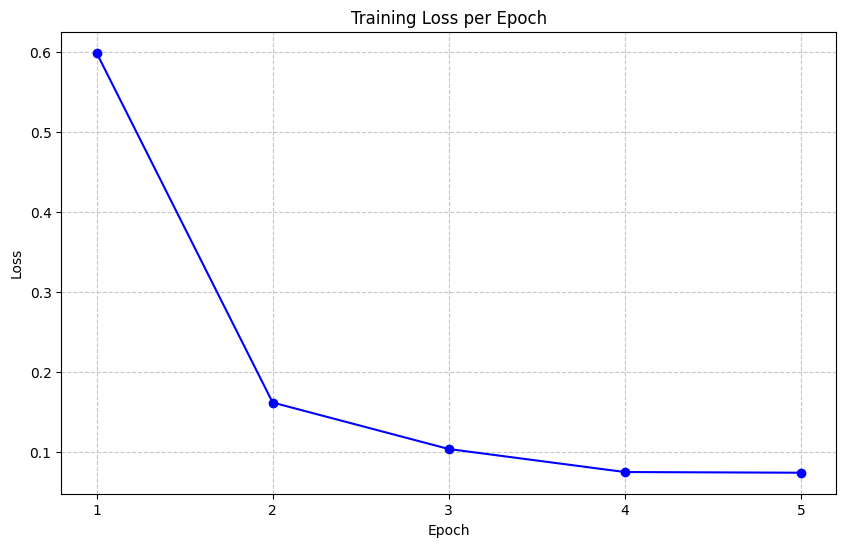

In [ ]:
# Training Loss Visualisation

plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linestyle='-', color='b')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, num_epochs + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 3. Evaluation and Final PredictionsAfter training the model, it is essential to evaluate how well it performs on unseen data. Evaluation helps us understand whether the model has learned generalisable patterns or has simply memorised the training data.

In this section, we:
- Measure model performance using validation accuracy
- Analyse predictions at the individual data-point level
- Examine model behavior using diagnostic plots

### 3.1 Evaluation Metrics and Bias-Variance Tradeoff

#### **3.1.1** Calculate Appropriate Evaluation Metrics to Assess Model Performance

For this multi-class classification problem, we use **accuracy** as the primary evaluation metric.

Accuracy measures the proportion of validation samples that are correctly classified by the model. Since the dataset is reasonably balanced across classes, accuracy provides a reliable indication of overall performance.

In [ ]:
# Model Evaluation

correct = 0
total = 0
model.eval() # Set model to evaluation mode

with torch.no_grad(): # Disable gradient tracking
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        outputs = model(inputs)

        # Get predictions from the maximum value
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the model on the {total} validation images: {accuracy:.2f}%')

Accuracy of the model on the 360 validation images: 97.22%


#### **3.1.2** Dataset DiagnosticsBeyond accuracy, diagnostic analysis helps assess whether the model is underfitting, overfitting, or generalising well

Analyse this using training and validation loss trends, along with dataset class distribution.

In [ ]:
# Training and Validation Loss Analysis

final_train_loss = train_losses[-1]
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Validation Accuracy: {accuracy:.2f}%")

# Diagnostic Interpretation
if final_train_loss < 0.1 and accuracy > 90:
    print("\nDiagnostic: The model shows high accuracy and low training loss.")
    print("The small gap between training performance and validation performance suggests low variance (minimal overfitting).")
else:
    print("\nDiagnostic: Check the loss curve for potential underfitting or overfitting.")

Final Training Loss: 0.0739
Validation Accuracy: 97.22%

Diagnostic: The model shows high accuracy and low training loss.
The small gap between training performance and validation performance suggests low variance (minimal overfitting).


### 3.2 Prediction AnalysisOverall accuracy provides a summary metric, but it does not reveal how individual predictions contribute to that score.

To better understand model behavior, we examine predictions at the individual image level, highlighting both correct and incorrect classifications.

#### **3.2.1** Visualise the prediction on a few sample images from validation set

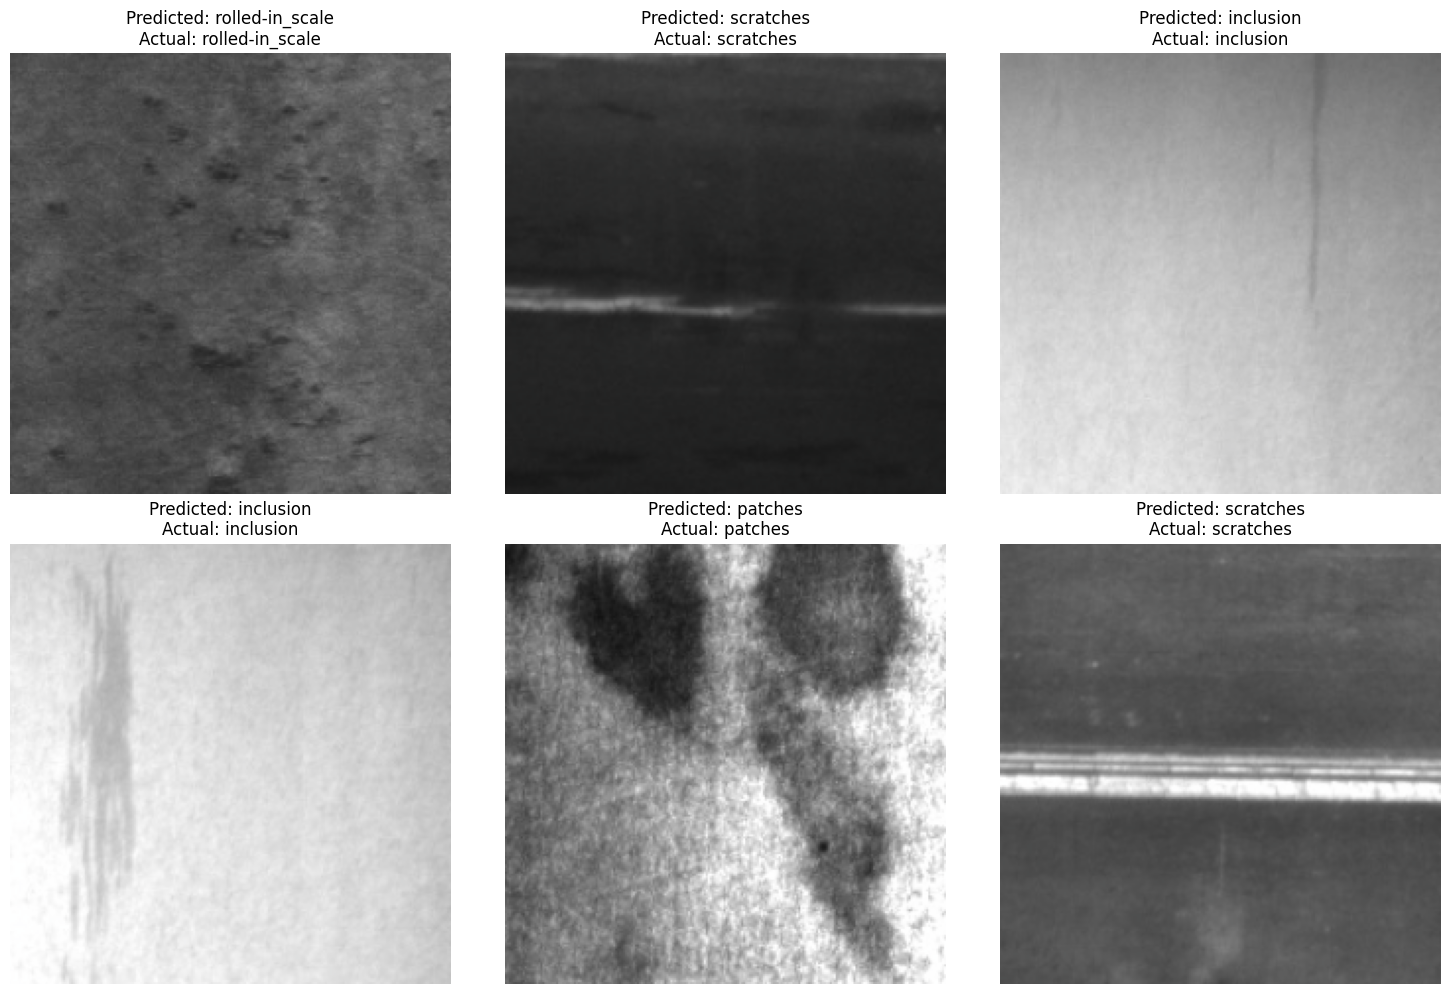

In [ ]:
# Visualisation of Validation Predictions (Shuffled for Diversity)

def visualize_predictions(model, dataset, num_images=6):
    model.eval()
    # Create a temporary loader with shuffle=True to see different classes
    temp_loader = DataLoader(dataset, batch_size=num_images, shuffle=True)

    images, labels = next(iter(temp_loader))
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    fig = plt.figure(figsize=(15, 10))
    for i in range(num_images):
        ax = plt.subplot(num_images // 3, 3, i + 1)
        ax.axis('off')

        # Unnormalize image for visualization
        img = images.cpu().data[i].numpy().transpose((1, 2, 0))
        img = np.array(IMAGENET_STD) * img + np.array(IMAGENET_MEAN)
        img = np.clip(img, 0, 1)

        ax.imshow(img)
        ax.set_title(f'Predicted: {idx_to_class[preds[i].item()]}\nActual: {idx_to_class[labels[i].item()]}')

    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_dataset)

## 4 Conclusion

### 4.1 Conclusion and insights

#### **4.1.1** Conclusion


### Final Project Reflection

Wrapping this up, I'm actually really surprised at how well the model performed! Here's a quick breakdown of what I did and what I learned from this project:

*   **Model Choice:** I went with **MobileNetV2**. Since I'm working in a notebook and don't have a massive supercomputer, I wanted something fast and lightweight. It was originally trained on ImageNet, so it already knew a lot about shapes and textures, which turned out to be perfect for finding defects on steel.
*   **The 'Freezing' Part:** This was the most interesting part for me. I 'froze' the main backbone of the model (over 2 million parameters!) and only trained a tiny new 'head' at the end (just 7,686 parameters). This meant the training only took a few minutes instead of hours, and it kept the model from forgetting the smart features it already knew.
*   **Results:** After just 5 epochs, the training loss dropped significantly from ~0.60 to ~0.07. When I ran it on the validation images (the stuff the model hadn't seen yet), it hit **97.22% accuracy**. Seeing the actual pictures with the 'Predicted' vs 'Actual' labels was satisfying because even the tricky defects like 'crazing' were being caught correctly.

**Key Insight:** You don't always need a massive dataset or weeks of training to get professional results. By using **Transfer Learning**, I was able to take a model trained on everyday objects and turn it into a specialized tool for industrial quality control with very little extra effort.